<a href="https://colab.research.google.com/github/saim9211/Machine-Learning-Stuff/blob/main/Applying%20Naive_Bayes_On_Movies_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Performing naive bayes on the Movies review Data set


In [ ]:
import kagglehub
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.


In [ ]:
import pandas as pd
import os

# Construct the full path to the CSV file
csv_file_path = os.path.join(path, 'IMDB Dataset.csv')

# Load the data into a pandas DataFrame
df = pd.read_csv(csv_file_path)

# Display the first few rows of the DataFrame to confirm loading
print(df.head())

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 781.4+ KB


In [ ]:
df['sentiment'] = df['sentiment'].replace({'positive': 1, 'negative': 0})
print(df.head())

                                              review  sentiment
0  One of the other reviewers has mentioned that ...          1
1  A wonderful little production. <br /><br />The...          1
2  I thought this was a wonderful way to spend ti...          1
3  Basically there's a family where a little boy ...          0
4  Petter Mattei's "Love in the Time of Money" is...          1


/tmp/ipykernel_9106/650000774.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['sentiment'] = df['sentiment'].replace({'positive': 1, 'negative': 0})


In [ ]:
import re
from bs4 import BeautifulSoup

def remove_html_tags(text):
    # Check if text is a string before processing
    if not isinstance(text, str):
        return text
    # Use BeautifulSoup to remove HTML tags
    soup = BeautifulSoup(text, 'html.parser')
    cleaned_text = soup.get_text()
    return cleaned_text

# Apply the function to the 'review' column
df['review'] = df['review'].apply(remove_html_tags)

# Display the first few rows to verify the changes
print(df.head())

                                              review  sentiment
0  One of the other reviewers has mentioned that ...          1
1  A wonderful little production. The filming tec...          1
2  I thought this was a wonderful way to spend ti...          1
3  Basically there's a family where a little boy ...          0
4  Petter Mattei's "Love in the Time of Money" is...          1


In [ ]:
df.sample(6)

,review,sentiment
35160,"I, for one, absolutely loved this movie.It is ...",1
2340,I love Aaron carter but even i expected pop st...,1
19584,Emma is my favourite Jane Austen novel - Emma ...,0
36359,to make up a movie-going audience - I'm certai...,0
5178,One Life Stand is an accomplished piece of fil...,1
40760,"First of all, in defense of JOAN FONTAINE, it ...",1


In [ ]:
import re

def clean_text_alphabetic(text):
    if not isinstance(text, str):
        return text
    # Replace non-alphabetic characters with a space
    # The regex '[^a-zA-Z]' matches any character that is NOT an uppercase or lowercase letter
    cleaned_text = re.sub(r'[^a-zA-Z]', ' ', text)
    # Replace multiple spaces with a single space
    cleaned_text = re.sub(r'\s+', ' ', cleaned_text)
    # Strip leading/trailing whitespace
    cleaned_text = cleaned_text.strip()
    return cleaned_text.lower() # Convert to lowercase for consistency

# Apply the cleaning function to the 'review' column
df['review'] = df['review'].apply(clean_text_alphabetic)

# Display the first few rows to verify the changes
print(df.head())

                                              review  sentiment
0  one of the other reviewers has mentioned that ...          1
1  a wonderful little production the filming tech...          1
2  i thought this was a wonderful way to spend ti...          1
3  basically there s a family where a little boy ...          0
4  petter mattei s love in the time of money is a...          1


In [ ]:
import re

def handle_negations(text):
    if not isinstance(text, str):
        return text

    # Expand common negative contractions and their broken forms
    text = re.sub(r'\b(don t|dont)\b', 'do not', text)
    text = re.sub(r'\b(didn t|didnt)\b', 'did not', text)
    text = re.sub(r'\b(won t|wont)\b', 'will not', text)
    text = re.sub(r'\b(can t|cant)\b', 'can not', text)
    text = re.sub(r'\b(isn t|isnt)\b', 'is not', text)
    text = re.sub(r'\b(aren t|arent)\b', 'are not', text)
    text = re.sub(r'\b(wasn t|wasnt)\b', 'was not', text)
    text = re.sub(r'\b(weren t|werent)\b', 'were not', text)
    text = re.sub(r'\b(haven t|havent)\b', 'have not', text)
    text = re.sub(r'\b(hasn t|hasnt)\b', 'has not', text)
    text = re.sub(r'\b(hadn t|hadnt)\b', 'had not', text)
    text = re.sub(r'\b(couldn t|couldnt)\b', 'could not', text)
    text = re.sub(r'\b(shouldn t|shouldnt)\b', 'should not', text)
    text = re.sub(r'\b(wouldn t|wouldnt)\b', 'would not', text)
    text = re.sub(r'\b(mustn t|mustnt)\b', 'must not', text)
    text = re.sub(r'\b(needn t|neednt)\b', 'need not', text)

    # Ensure 'no' is handled correctly (it should already be a separate word)
    # No specific regex needed for 'no' itself if it's already a word due to previous cleaning.

    # Clean up any potential multiple spaces that might result from replacements
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply the negation handling function to the 'review' column
df['review'] = df['review'].apply(handle_negations)

# Display the first few rows to verify the changes
print(df.head())

                                              review  sentiment
0  one of the other reviewers has mentioned that ...          1
1  a wonderful little production the filming tech...          1
2  i thought this was a wonderful way to spend ti...          1
3  basically there s a family where a little boy ...          0
4  petter mattei s love in the time of money is a...          1


In [ ]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    if not isinstance(text, str):
        return text
    # Split the text into words, filter out stopwords, and join them back
    return ' '.join([word for word in str(text).split() if word not in stop_words])

# Apply the stopword removal function to the 'review' column
df['review'] = df['review'].apply(remove_stopwords)

# Display the first few rows to verify the changes
print(df.head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


                                              review  sentiment
0  one reviewers mentioned watching oz episode ho...          1
1  wonderful little production filming technique ...          1
2  thought wonderful way spend time hot summer we...          1
3  basically family little boy jake thinks zombie...          0
4  petter mattei love time money visually stunnin...          1



--- Multinomial Naive Bayes Model Performance ---
Accuracy: 0.8550
Precision: 0.8528
Recall: 0.8609

Confusion Matrix:
[[4212  749]
 [ 701 4338]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.85      0.85      4961
           1       0.85      0.86      0.86      5039

    accuracy                           0.85     10000
   macro avg       0.86      0.85      0.85     10000
weighted avg       0.86      0.85      0.85     10000



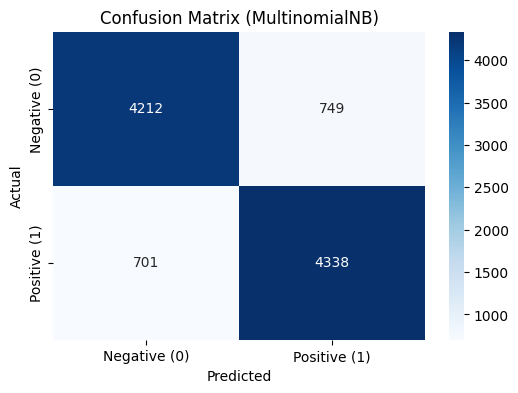


--- Gaussian Naive Bayes Model Performance ---
Accuracy: 0.7971
Precision: 0.8038
Recall: 0.7902

Confusion Matrix:
[[3989  972]
 [1057 3982]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.80      0.80      4961
           1       0.80      0.79      0.80      5039

    accuracy                           0.80     10000
   macro avg       0.80      0.80      0.80     10000
weighted avg       0.80      0.80      0.80     10000



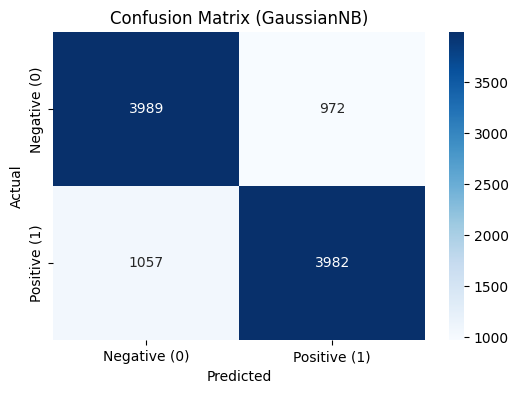

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB,GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Text Vectorization
# Using TF-IDF Vectorizer to convert text reviews into numerical features
tfidf_vectorizer = TfidfVectorizer(max_features=5000) # Limiting features to 5000 for efficiency
X = tfidf_vectorizer.fit_transform(df['review'])
y = df['sentiment']

# 2. Splitting Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Model Training
g_naive_bayes=GaussianNB()
g_naive_bayes.fit(X_train.toarray(), y_train)
naive_bayes_model = MultinomialNB()
naive_bayes_model.fit(X_train, y_train)

# 4. Prediction
y_pred = naive_bayes_model.predict(X_test)
y_pred_g=g_naive_bayes.predict(X_test.toarray())

# 5. Evaluation for Multinomial Naive Bayes
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print("\n--- Multinomial Naive Bayes Model Performance ---")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Plotting the Confusion Matrix for Multinomial Naive Bayes
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative (0)', 'Positive (1)'], yticklabels=['Negative (0)', 'Positive (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (MultinomialNB)')
plt.show()

# 6. Evaluation for Gaussian Naive Bayes
accuracy_g = accuracy_score(y_test, y_pred_g)
precision_g = precision_score(y_test, y_pred_g)
recall_g = recall_score(y_test, y_pred_g)
conf_matrix_g = confusion_matrix(y_test, y_pred_g)

print("\n--- Gaussian Naive Bayes Model Performance ---")
print(f"Accuracy: {accuracy_g:.4f}")
print(f"Precision: {precision_g:.4f}")
print(f"Recall: {recall_g:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix_g)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_g))

# Plotting the Confusion Matrix for Gaussian Naive Bayes
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_g, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative (0)', 'Positive (1)'], yticklabels=['Negative (0)', 'Positive (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (GaussianNB)')
plt.show()

In [ ]:
if[]:
  print("yes")
else:
  print("No")

No
